In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import folium
from folium.plugins import MarkerCluster

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from lightgbm import LGBMClassifier
from sklearn.cluster import KMeans
sns.set_theme()

In [ ]:
df_map = pd.read_csv(
    r'C:\Fause\Programas\EngSoft\repos\ML-Transportes\PBIC\acidentes_pbic_somas.csv',
    encoding='utf-8',
    parse_dates=['data_inversa'],
    dayfirst=True,
    low_memory=False
)

print("Shape inicial:", df_map.shape)


Shape inicial: (1678326, 53)


In [ ]:
df_map = df_map.copy()

df_map = df_map.drop_duplicates(subset=["id", "pesid"])

In [ ]:
import pandas as pd
import numpy as np
import folium
from folium.plugins import MarkerCluster
from datetime import datetime

# =============================
# 1️⃣ Limpeza e Padronização (O Pulo do Gato)
# =============================


# Função para garantir que a BR seja uma string limpa (ex: "116")
def limpar_br(df):
    return df["br"].astype(str).str.replace(r'\.0$', '', regex=True).str.strip()

df_map["br"] = limpar_br(df_map)

# =============================
# FILTRO DE RODOVIA (BR)
# =============================

br_escolhida = input("Digite a BR que deseja visualizar (ex: 116) ou pressione ENTER para todas: ")

if br_escolhida.strip() != "":
    df_map = df_map[df_map["br"] == br_escolhida.strip()]
    print(f"Filtrando apenas BR {br_escolhida}")
else:
    print("Mostrando todas as rodovias")

if df_map.empty:
    print("Nenhum dado encontrado para essa BR.")
    exit()
# Limpeza de coordenadas e KM
cols = ["latitude", "longitude", "km"]
for col in cols:
    df_map[col] = pd.to_numeric(df_map[col].astype(str).str.replace(",", "."), errors="coerce")

df_map = df_map.dropna(subset=["latitude", "longitude", "km"])
df_map["km_bin"] = (df_map["km"] // 5) * 5

# =============================
# 2️⃣ Agregação
# =============================
#AQUI
# Cálculo de severidade no DF original
df_map["severity_index"] = (
    4 * df_map["Sum_Mortos"] +
    2 * df_map["Sum_Feridos_Graves"] +
    1 * df_map["Sum_Feridos_Leves"]
)
#AQUI
df_segmento = df_map.groupby(["br", "uf", "km_bin"]).agg(
    severity_index=("severity_index", "mean"),
    n_acidentes=("severity_index", "count"),
    total_mortos=("Sum_Mortos", "sum"),
    total_feridos_graves=("Sum_Feridos_Graves", "sum"),
    total_feridos_leves=("Sum_Feridos_Leves", "sum")
).reset_index()

df_segmento["risk_score"] = df_segmento["severity_index"] * np.log1p(df_segmento["n_acidentes"])
df_segmento["taxa_mortalidade"] = (
    df_segmento["total_mortos"] /
    (df_segmento["total_mortos"] +
     df_segmento["total_feridos_graves"] +
     df_segmento["total_feridos_leves"])
)

def classificar_gravidade(row):
    if row["total_mortos"] > 0: return "Acidente com mortos"
    if (row["total_feridos_graves"] > 0) or (row["total_feridos_leves"] > 0): return "Sinistro de média gravidade"
    return "Sinistro sem gravidade"

df_segmento["gravidade"] = df_segmento.apply(classificar_gravidade, axis=1)

# =============================
# 3️⃣ Mapa e Plotagem
# =============================

m = folium.Map(
    location=[df_map["latitude"].median(), df_map["longitude"].median()],
    zoom_start=6,
    #tiles="CartoDB positron" # Evita o erro 403 Access Blocked
)

# Camadas
layers = {
    "Acidente com mortos": MarkerCluster(name="🔴 Acidente com mortos").add_to(m),
    "Sinistro de média gravidade": MarkerCluster(name="🟠 Média gravidade").add_to(m),
    "Sinistro sem gravidade": MarkerCluster(name="🟢 Sem gravidade").add_to(m)
}

segmentos_grupo = df_map.groupby(["br", "uf", "km_bin"])

for _, row in df_segmento.iterrows():
    try:
        # Busca o grupo usando as chaves limpas
        grupo = segmentos_grupo.get_group((row["br"], row["uf"], row["km_bin"]))
        # Ordena pelo KM e pega o primeiro ponto (início do trecho)
        ponto_ref = grupo.sort_values("km").iloc[0]

        lat = ponto_ref["latitude"]
        lon = ponto_ref["longitude"]
    except KeyError:
        continue # Se não achar, pula

    # Define cor
    cor = "red" if row["gravidade"] == "Acidente com mortos" else "orange" if row["gravidade"] == "Sinistro de média gravidade" else "green"

    # Popup
    veiculos = grupo["tipo_veiculo"].value_counts().head(3)
    veiculo_txt = "<br>".join([f"{v}: {c}" for v, c in veiculos.items()])

    popup_html = f"""
<b>BR:</b> {row['br']} - {row['uf']} | <b>KM:</b> {row['km_bin']}<br>
<b>Gravidade:</b> {row['gravidade']}<br>

<hr>
<b> Estatísticas do trecho:</b><br>
• Total de acidentes: {row['n_acidentes']}<br>
• Mortos: {row['total_mortos']}<br>
• Feridos graves: {row['total_feridos_graves']}<br>
• Feridos leves: {row['total_feridos_leves']}<br>

<hr>
<b> Top Veículos:</b><br>
{veiculo_txt}
"""

    # CircleMarker é melhor que Circle porque o tamanho é fixo em pixels
    folium.CircleMarker(
        location=[lat, lon],
        radius=7 + (np.log1p(row["total_mortos"]) * 3),
        color=cor,
        fill=True,
        fill_opacity=0.7,
        popup=folium.Popup(popup_html, max_width=250)
    ).add_to(layers[row["gravidade"]])

folium.LayerControl().add_to(m)
path = f"C:/Fause/Programas/EngSoft/repos/ML-Transportes/PBIC\EtapaML\Final\MapsGeral/mapa_sum.html"
m.save(path)
print(f"Mapa gerado com sucesso em: {path}")

<>:140: SyntaxWarning: invalid escape sequence '\E'
<>:140: SyntaxWarning: invalid escape sequence '\E'
C:\Users\fause\AppData\Local\Temp\ipykernel_14912\535614040.py:140: SyntaxWarning: invalid escape sequence '\E'
  path = f"C:/Fause/Programas/EngSoft/repos/ML-Transportes/PBIC\EtapaML\Final\MapsGeral/mapa_sum.html"


Mostrando todas as rodovias
Mapa gerado com sucesso em: C:/Fause/Programas/EngSoft/repos/ML-Transportes/PBIC\EtapaML\Final\MapsGeral/mapa_sum.html


In [ ]:
print("BRs disponíveis no dataset:")
print(df_map["br"].unique())

BRs disponíveis no dataset:
<StringArray>
['153', '116', '101', '364', '319', '369', '104', '290', '470', '282',
 ...
 '433', '430', '437', '342', '494', '498', '466', '363', '307', '431']
Length: 126, dtype: str


In [ ]:
print(df_segmento['total_feridos_graves'].unique())

[  1.   3.   0.   4.  13.   5.  12.   6.   9.   7.  16.  22.  52.  59.
  70.  10.   8.   2.  11.  15.  25.  21.  35.  14.  18.  19.  17.  36.
  23.  20.  27.  37.  30.  31.  28.  84.  24.  26.  67. 118.  33.  29.
  76. 127. 193.  97.  44. 105. 120. 112.  64. 124.  83. 101.  63.  62.
 157. 108.  69.  45.  43.  54.  53.  56.  32.  60.  47.  38.  55.  91.
  34.  77.  90. 138.  82. 160. 156.  74. 110.  79.  58.  94. 187. 280.
 289. 172.  39.  65.  40.  48.  61.  41.  57.  87. 111.  96.  71.  42.
  51.  46.  50.  93.  49. 119.  81. 104.  72.  89.  75.  68.  73.  85.
 132. 149.  66. 113. 139.  92.  98.  95.  78. 109. 128. 100.  88. 102.]


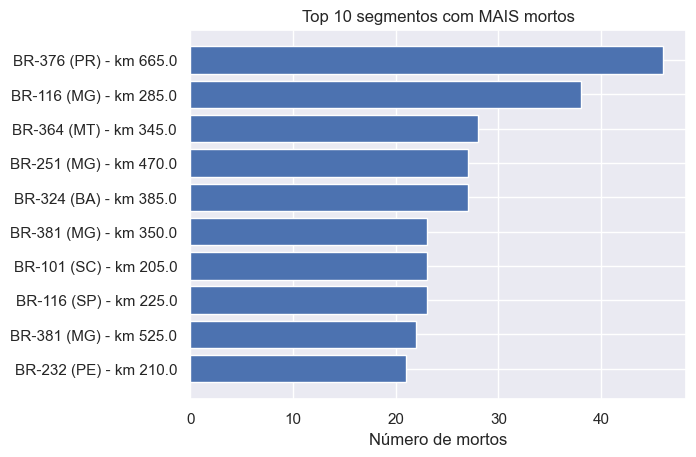

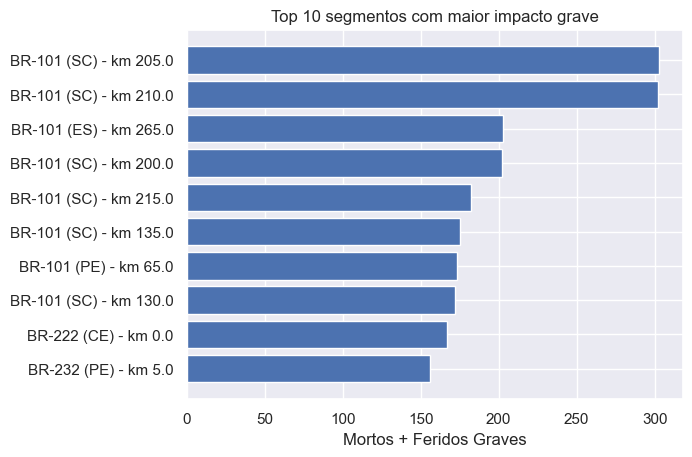

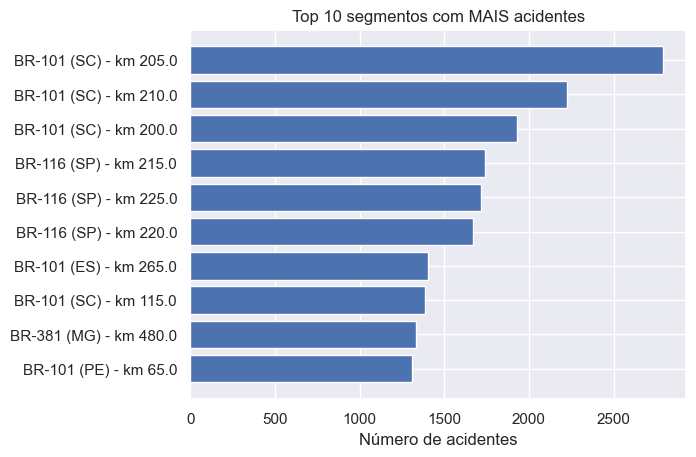

In [ ]:
import matplotlib.pyplot as plt

# =============================
# 1️⃣ Filtrar apenas acidentes com mortos
# =============================

df_segmento["br"] = df_segmento["br"].astype(str)

df_mortos = df_segmento[
    df_segmento["gravidade"] == "Acidente com mortos"
].copy()

# =============================
# 2️⃣ TOP 10 - MAIS MORTOS
# =============================

top10_mortos = df_mortos.sort_values(
    "total_mortos", ascending=False
).head(10).copy()

top10_mortos["segmento"] = (
    "BR-" + top10_mortos["br"] + " (" +
    top10_mortos["uf"] + ") - km " +
    top10_mortos["km_bin"].astype(str)
)

plt.figure()

plt.barh(
    top10_mortos["segmento"],
    top10_mortos["total_mortos"]
)

plt.xlabel("Número de mortos")
plt.title("Top 10 segmentos com MAIS mortos")
plt.gca().invert_yaxis()

plt.show()

# =============================
# 3️⃣ TOP 10 - MAIS IMPACTO GRAVE (Mortos + Feridos Graves)
# =============================

df_segmento["impacto_grave"] = (
    df_segmento["total_mortos"] + df_segmento["total_feridos_graves"]
)

top10_impacto = df_segmento.sort_values(
    "impacto_grave", ascending=False
).head(10).copy()

top10_impacto["segmento"] = (
    "BR-" + top10_impacto["br"] + " (" +
    top10_impacto["uf"] + ") - km " +
    top10_impacto["km_bin"].astype(str)
)

plt.figure()

plt.barh(
    top10_impacto["segmento"],
    top10_impacto["impacto_grave"]
)

plt.xlabel("Mortos + Feridos Graves")
plt.title("Top 10 segmentos com maior impacto grave")
plt.gca().invert_yaxis()

plt.show()
# =============================
# 4️⃣ TOP 10 - MAIS ACIDENTES (Volume)
# =============================

top10_acidentes = df_segmento.sort_values(
    "n_acidentes", ascending=False
).head(10).copy()

top10_acidentes["segmento"] = (
    "BR-" + top10_acidentes["br"] + " (" +
    top10_acidentes["uf"] + ") - km " +
    top10_acidentes["km_bin"].astype(str)
)

plt.figure()

plt.barh(
    top10_acidentes["segmento"],
    top10_acidentes["n_acidentes"]
)

plt.xlabel("Número de acidentes")
plt.title("Top 10 segmentos com MAIS acidentes")
plt.gca().invert_yaxis()

plt.show()


📊 Análise detalhada por TRECHO (não mistura estados)

🚨 ===== BR-101 | SC | km 205.0-210.0 =====
⏰ Horários críticos:
hora
18    270
7     226
17    224
dtype: int64

🌧️ Clima dominante:
condicao_metereologica
Céu Claro    1886
Nublado       719
Chuva         266
Name: count, dtype: int64

🌙 Fase do dia:
fase_dia
Pleno dia      1993
Plena Noite     991
Anoitecer       167
Amanhecer        95
Name: count, dtype: int64


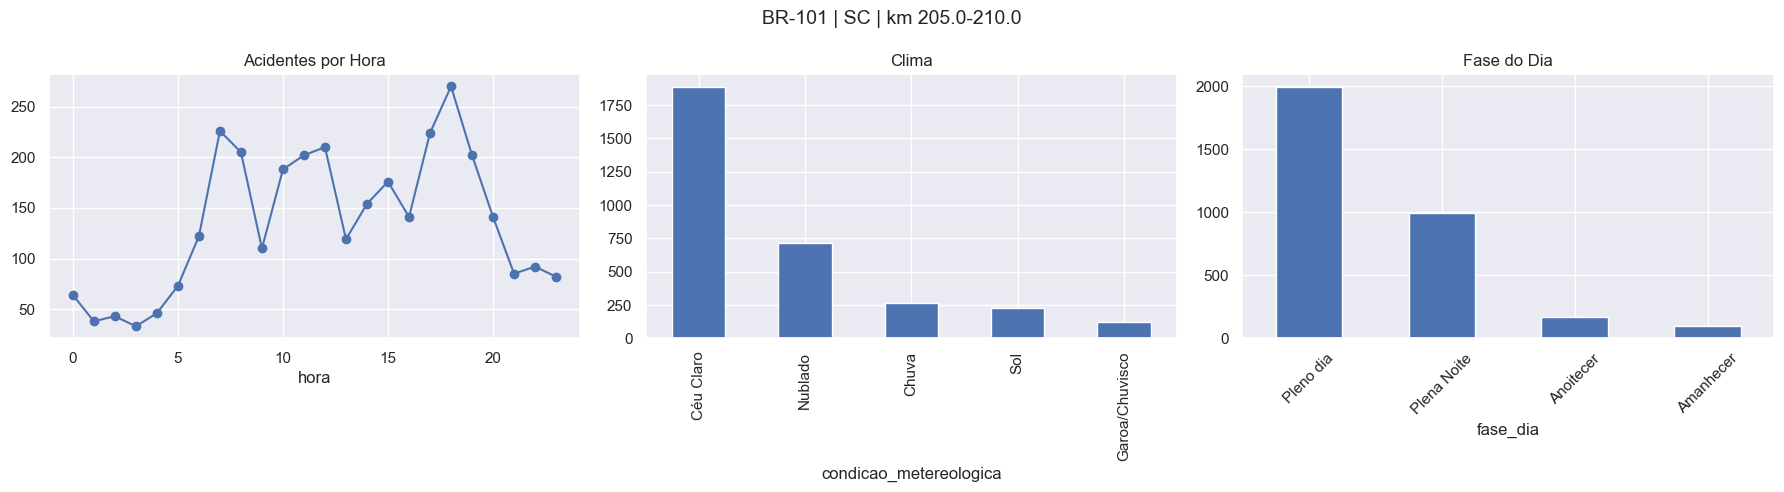


🚨 ===== BR-101 | SC | km 210.0-215.0 =====
⏰ Horários críticos:
hora
7     281
18    231
8     230
dtype: int64

🌧️ Clima dominante:
condicao_metereologica
Céu Claro    1494
Nublado       629
Chuva         228
Name: count, dtype: int64

🌙 Fase do dia:
fase_dia
Pleno dia      1717
Plena Noite     756
Anoitecer       119
Amanhecer        86
Name: count, dtype: int64


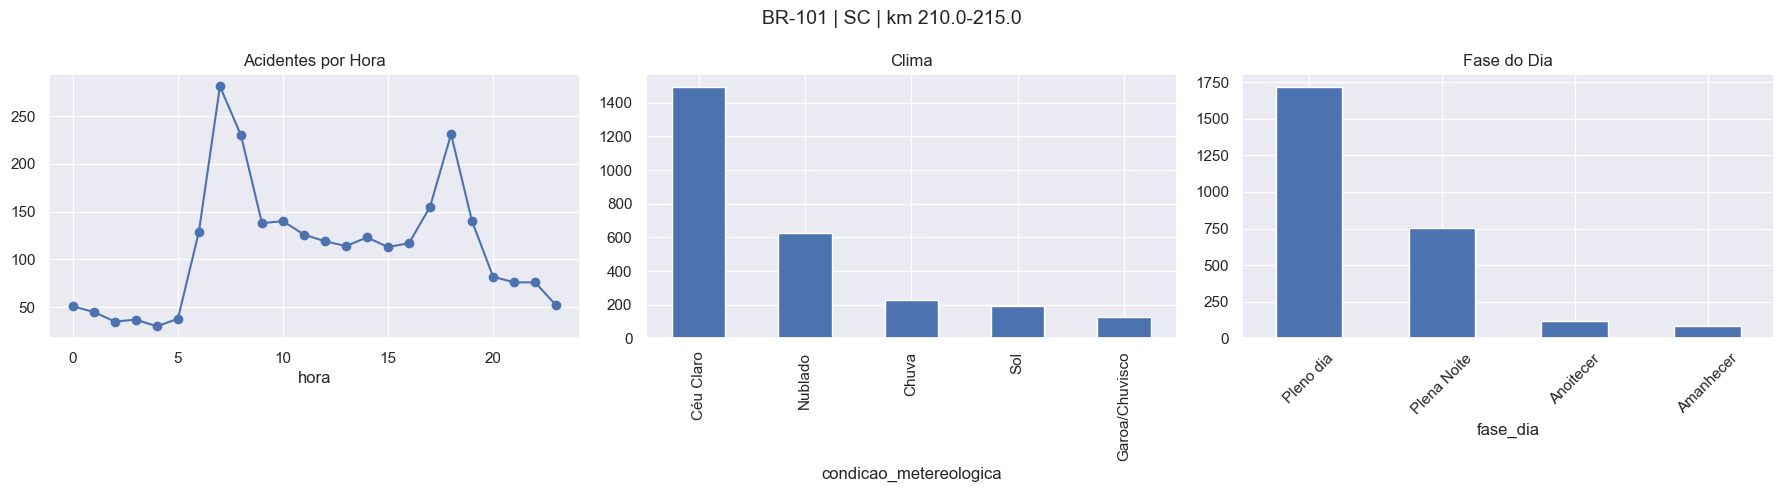


🚨 ===== BR-101 | ES | km 265.0-270.0 =====
⏰ Horários críticos:
hora
7     201
8     162
18    134
dtype: int64

🌧️ Clima dominante:
condicao_metereologica
Céu Claro    992
Nublado      345
Sol          212
Name: count, dtype: int64

🌙 Fase do dia:
fase_dia
Pleno dia      1111
Plena Noite     458
Anoitecer       109
Amanhecer        47
Name: count, dtype: int64


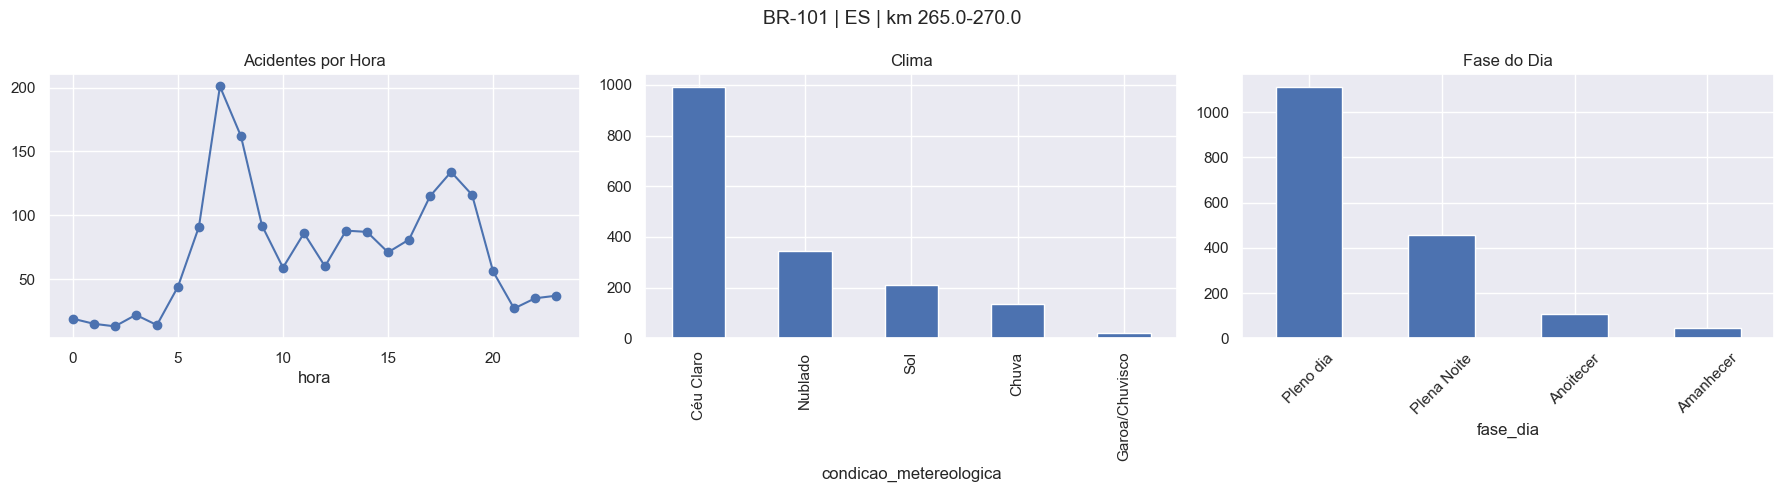


🚨 ===== BR-101 | SC | km 200.0-205.0 =====
⏰ Horários críticos:
hora
18    212
8     210
7     180
dtype: int64

🌧️ Clima dominante:
condicao_metereologica
Céu Claro    1309
Nublado       511
Chuva         211
Name: count, dtype: int64

🌙 Fase do dia:
fase_dia
Pleno dia      1481
Plena Noite     653
Anoitecer       130
Amanhecer        58
Name: count, dtype: int64


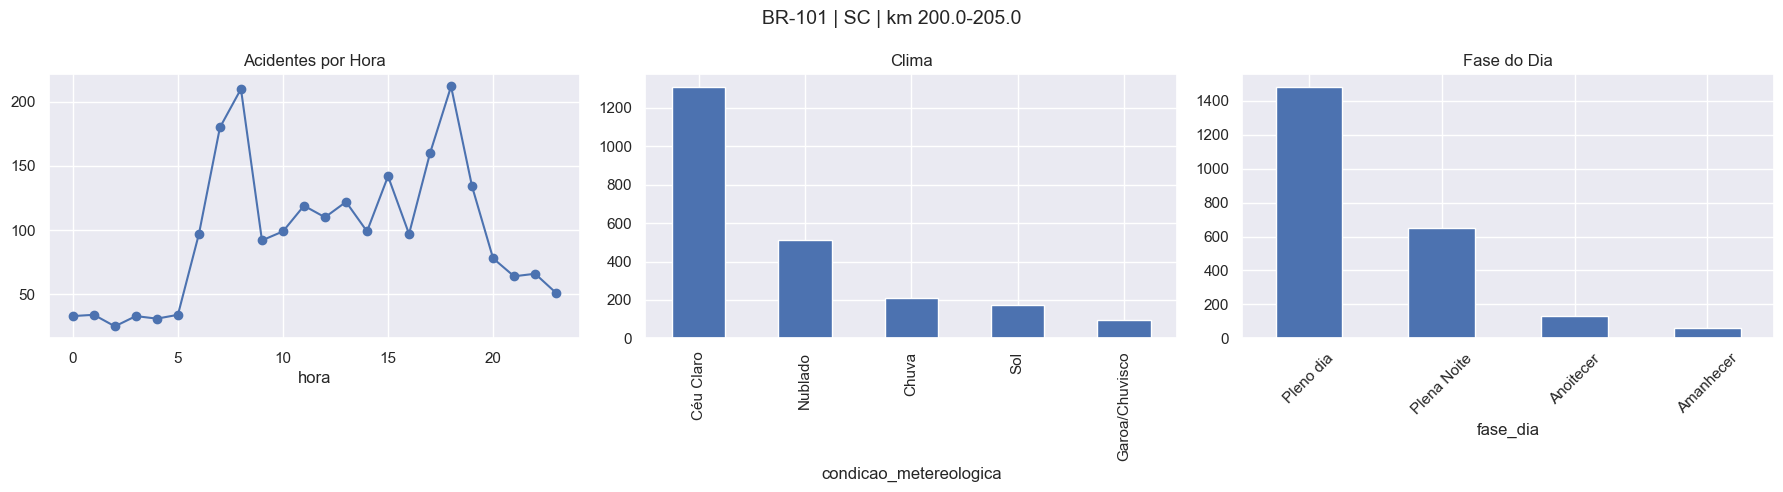


🚨 ===== BR-101 | SC | km 215.0-220.0 =====
⏰ Horários críticos:
hora
7     149
18    136
19     95
dtype: int64

🌧️ Clima dominante:
condicao_metereologica
Céu Claro    720
Nublado      346
Chuva        128
Name: count, dtype: int64

🌙 Fase do dia:
fase_dia
Pleno dia      787
Plena Noite    492
Anoitecer       55
Amanhecer       37
Name: count, dtype: int64


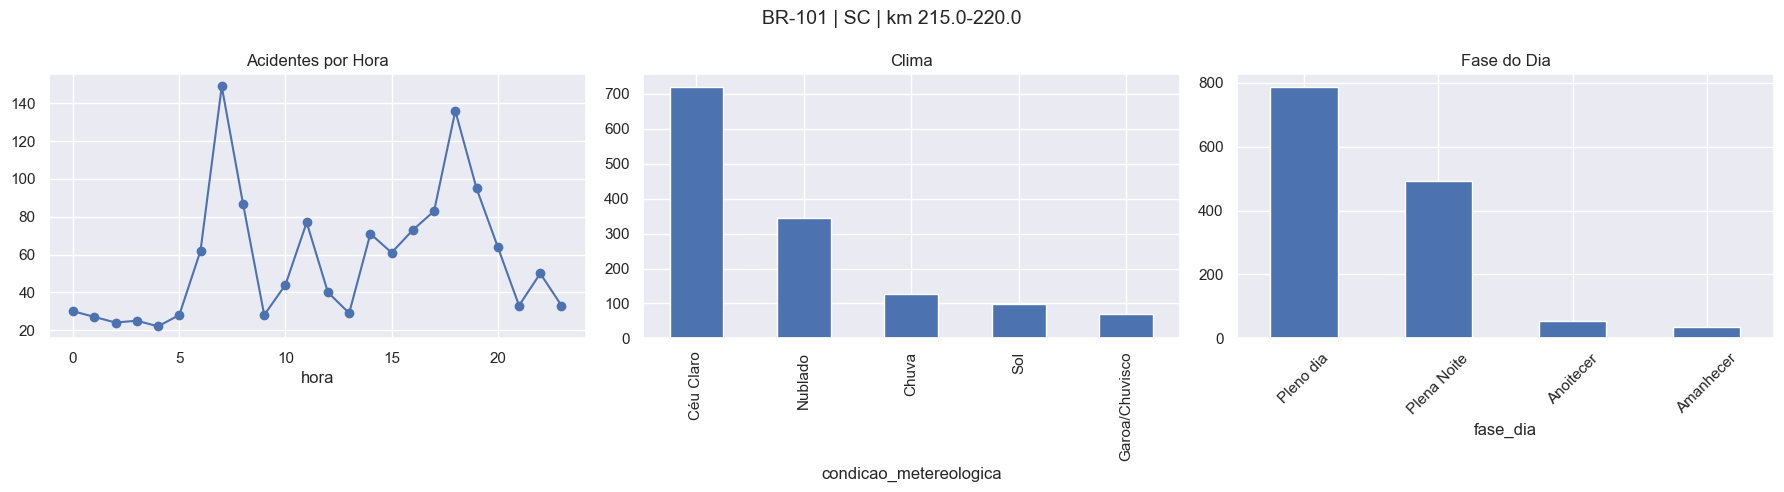


🚨 ===== BR-101 | SC | km 135.0-140.0 =====
⏰ Horários críticos:
hora
18    102
16     93
17     76
dtype: int64

🌧️ Clima dominante:
condicao_metereologica
Céu Claro    659
Nublado      390
Chuva        145
Name: count, dtype: int64

🌙 Fase do dia:
fase_dia
Pleno dia      783
Plena Noite    436
Anoitecer       80
Amanhecer       36
Name: count, dtype: int64


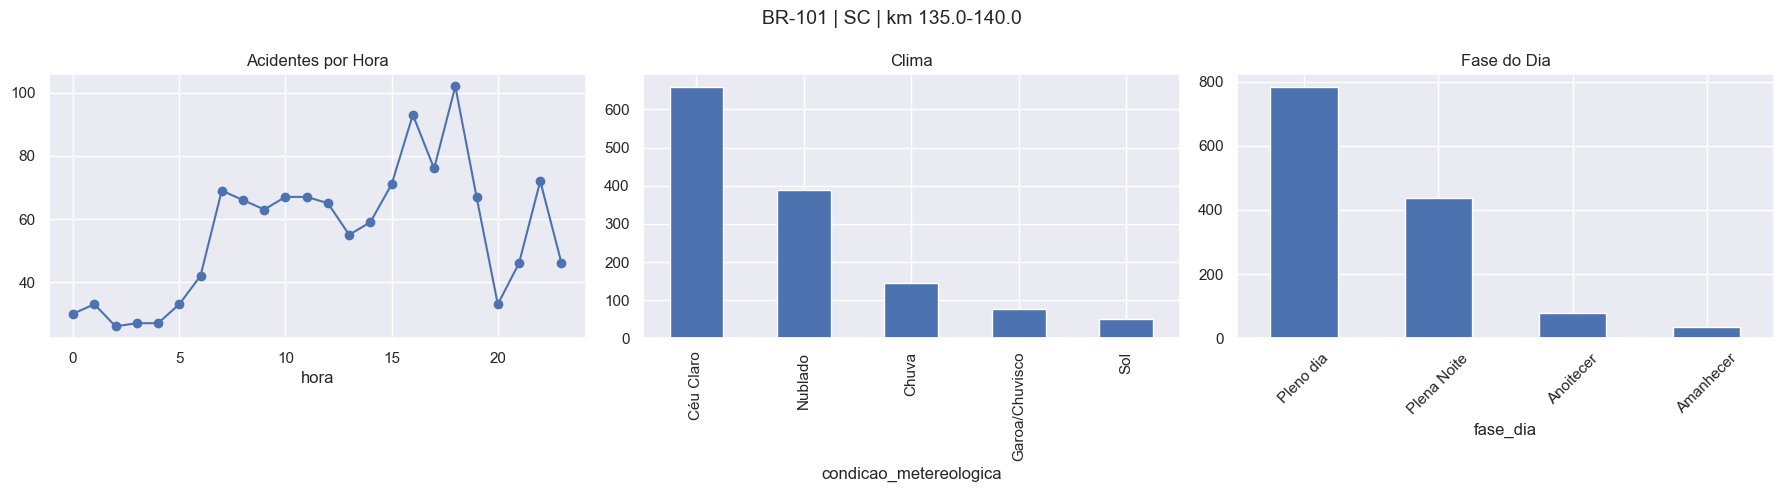


🚨 ===== BR-101 | PE | km 65.0-70.0 =====
⏰ Horários críticos:
hora
7     138
15    115
8     108
dtype: int64

🌧️ Clima dominante:
condicao_metereologica
Céu Claro    979
Nublado      223
Sol          194
Name: count, dtype: int64

🌙 Fase do dia:
fase_dia
Pleno dia      1118
Plena Noite     361
Anoitecer        54
Amanhecer        25
Name: count, dtype: int64


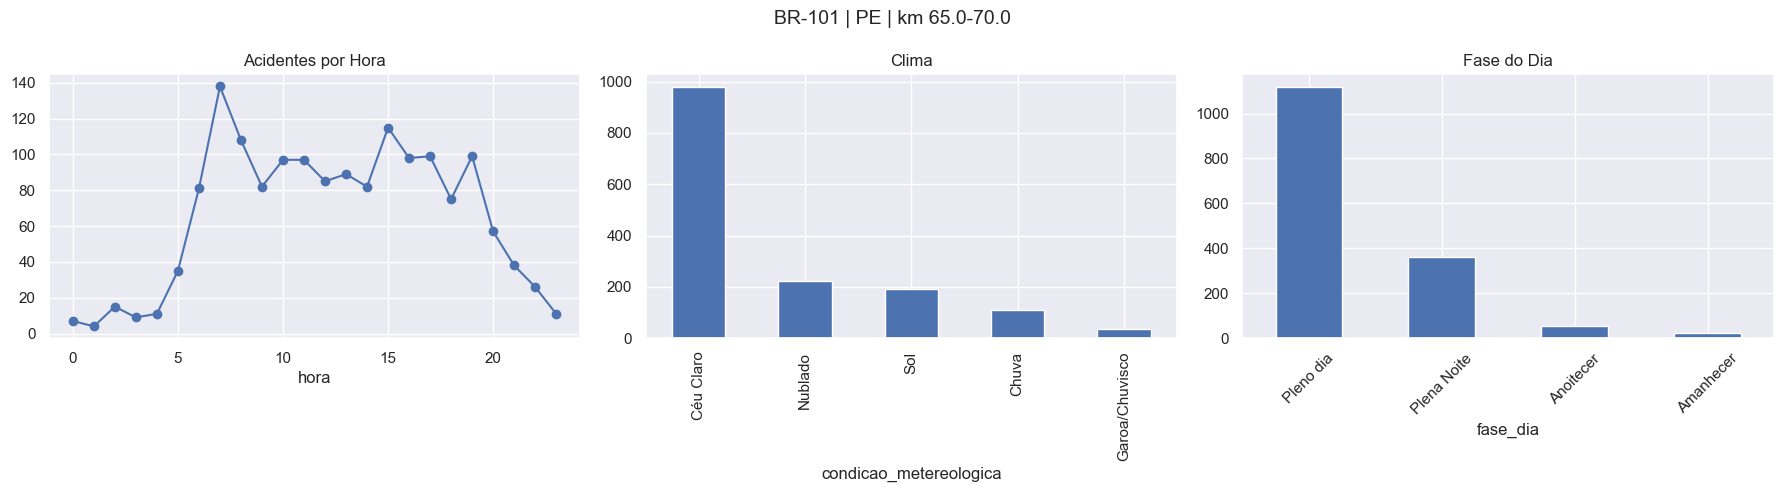


🚨 ===== BR-101 | SC | km 130.0-135.0 =====
⏰ Horários críticos:
hora
7     122
18    115
8     105
dtype: int64

🌧️ Clima dominante:
condicao_metereologica
Céu Claro    716
Nublado      359
Sol          106
Name: count, dtype: int64

🌙 Fase do dia:
fase_dia
Pleno dia      792
Plena Noite    464
Anoitecer       68
Amanhecer       28
Name: count, dtype: int64


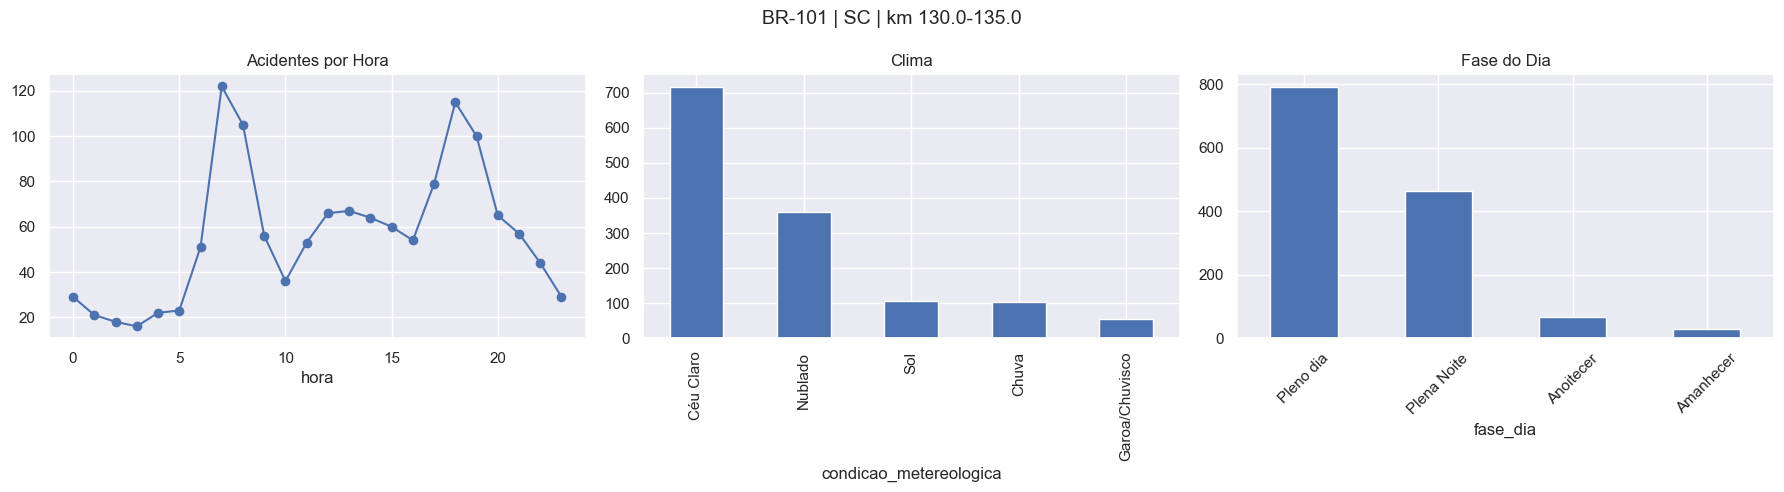


🚨 ===== BR-222 | CE | km 0.0-5.0 =====
⏰ Horários críticos:
hora
7     139
17    127
18    112
dtype: int64

🌧️ Clima dominante:
condicao_metereologica
Céu Claro    1123
Nublado       120
Sol            91
Name: count, dtype: int64

🌙 Fase do dia:
fase_dia
Pleno dia      859
Plena Noite    411
Anoitecer       97
Amanhecer       36
Name: count, dtype: int64


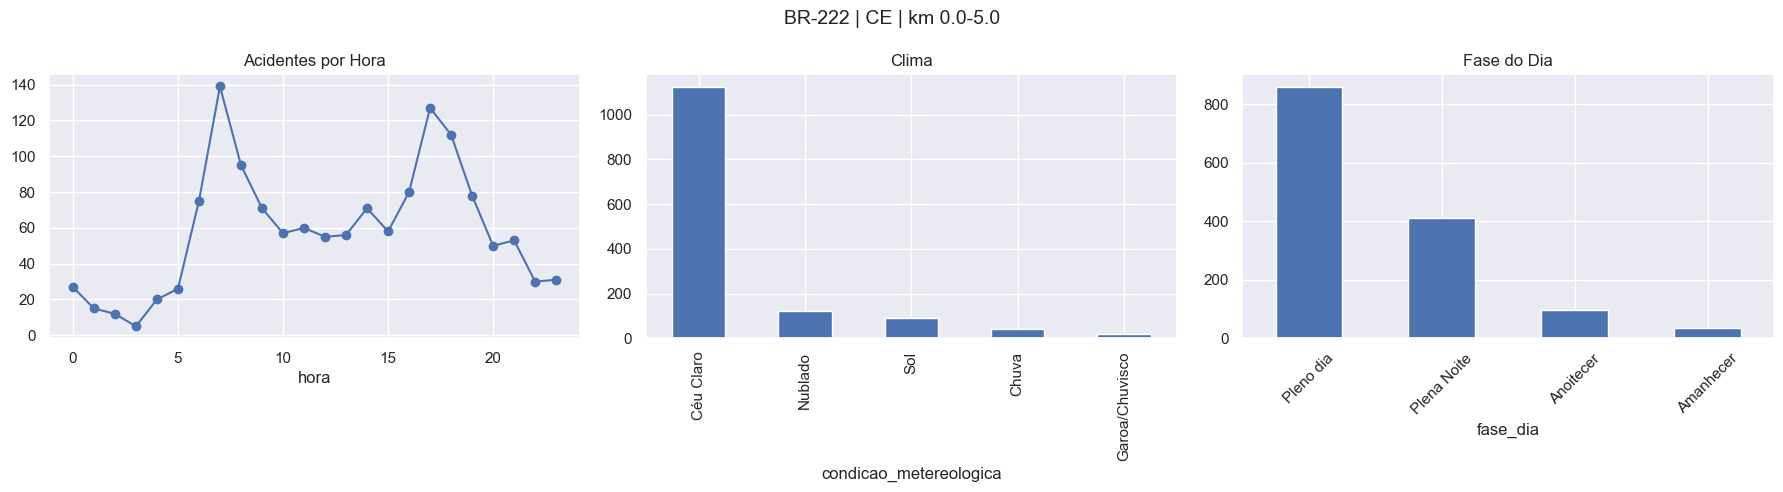


🚨 ===== BR-232 | PE | km 5.0-10.0 =====
⏰ Horários críticos:
hora
7     107
8      99
16     85
dtype: int64

🌧️ Clima dominante:
condicao_metereologica
Céu Claro    763
Nublado      153
Sol          117
Name: count, dtype: int64

🌙 Fase do dia:
fase_dia
Pleno dia      756
Plena Noite    267
Anoitecer       70
Amanhecer       19
Name: count, dtype: int64


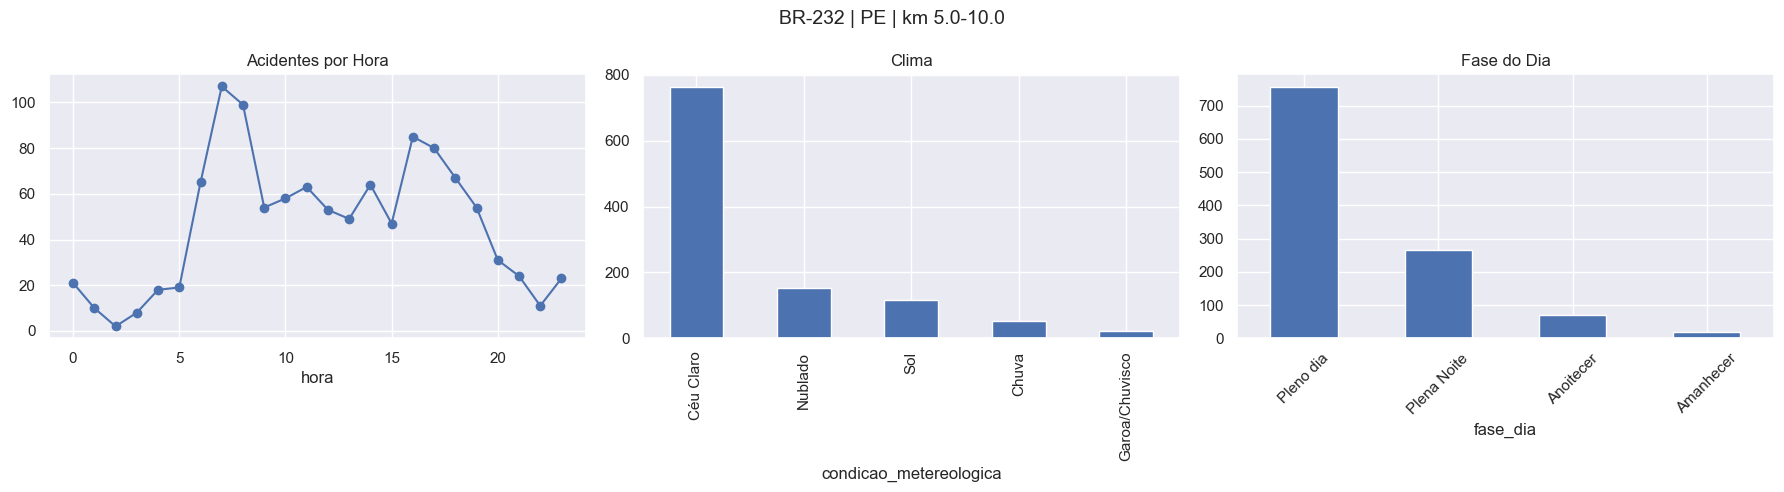

In [ ]:
# =============================
# 🔥 5️⃣ ANÁLISE DETALHADA POR TRECHO (BR + UF + KM)
# =============================

df_base = df_map  # 👉 ajuste se necessário

# Garantir km_bin
df_base['km'] = pd.to_numeric(df_base['km'], errors='coerce')

# 🔥 MUDANÇA AQUI: de 10 → 5
df_base['km_bin'] = (df_base['km'] // 5) * 5

# Filtrar apenas os trechos críticos
df_top = df_base.merge(
    top10_impacto[['br', 'uf', 'km_bin']],
    on=['br', 'uf', 'km_bin'],
    how='inner'
)

print("\n📊 Análise detalhada por TRECHO (não mistura estados)")

# =============================
# 🔁 Loop por TRECHO (CORRETO)
# =============================

for row in top10_impacto.itertuples():

    br = row.br
    uf = row.uf
    km_bin = row.km_bin

    df_trecho = df_top[
        (df_top['br'] == br) &
        (df_top['uf'] == uf) &
        (df_top['km_bin'] == km_bin)
    ]

    if len(df_trecho) == 0:
        continue

    print(f"\n🚨 ===== BR-{br} | {uf} | km {km_bin}-{km_bin+5} =====")

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(f'BR-{br} | {uf} | km {km_bin}-{km_bin+5}', fontsize=14)

    # =============================
    # ⏰ HORÁRIO
    # =============================
    if 'hora' in df_trecho.columns:
        hora_counts = df_trecho.groupby('hora').size()

        hora_counts.plot(kind='line', marker='o', ax=axes[0])
        axes[0].set_title("Acidentes por Hora")

        print("⏰ Horários críticos:")
        print(hora_counts.nlargest(3))

    # =============================
    # 🌧️ CLIMA
    # =============================
    if 'condicao_metereologica' in df_trecho.columns:
        clima_counts = df_trecho['condicao_metereologica'].value_counts().head(5)

        clima_counts.plot(kind='bar', ax=axes[1])
        axes[1].set_title("Clima")

        print("\n🌧️ Clima dominante:")
        print(clima_counts.head(3))

    # =============================
    # 🌙 FASE DO DIA
    # =============================
    if 'fase_dia' in df_trecho.columns:
        fase_counts = df_trecho['fase_dia'].value_counts()

        fase_counts.plot(kind='bar', ax=axes[2])
        axes[2].set_title("Fase do Dia")
        axes[2].tick_params(axis='x', rotation=45)

        print("\n🌙 Fase do dia:")
        print(fase_counts)

    plt.tight_layout()
    plt.show()